In [1]:
# Cell 1: Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


TensorFlow version: 2.16.1
GPU Available: []


In [4]:
# Cell 2: Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
MODEL_NAME = 'plant_species_identifier'

# Paths (relative to notebooks/ folder)
PROCESSED_DATA = r'../data/processed'
MODEL_OUTPUT   = r'../models'
OUTPUTS_DIR    = r'../outputs'

# Create directories
os.makedirs(MODEL_OUTPUT, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Load species mapping
species_df = pd.read_csv(os.path.join(PROCESSED_DATA, 'species_mapping.csv'))
NUM_CLASSES = len(species_df)
SPECIES_NAMES = species_df['species_name'].tolist()

print(f"Number of species: {NUM_CLASSES}")
print(f"\n✅ Species loaded:")
for idx, name in enumerate(SPECIES_NAMES[:10]):
    print(f"  {idx:2d}: {name}")
if NUM_CLASSES > 10:
    print(f"  ... and {NUM_CLASSES-10} more")


Number of species: 30

✅ Species loaded:
   0: Alpinia Galanga (Rasna)
   1: Amaranthus Viridis (Arive-Dantu)
   2: Artocarpus Heterophyllus (Jackfruit)
   3: Azadirachta Indica (Neem)
   4: Basella Alba (Basale)
   5: Brassica Juncea (Indian Mustard)
   6: Carissa Carandas (Karanda)
   7: Citrus Limon (Lemon)
   8: Ficus Auriculata (Roxburgh fig)
   9: Ficus Religiosa (Peepal Tree)
  ... and 20 more


In [5]:
# Cell 3: Create Data Generators with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    f'{PROCESSED_DATA}/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    f'{PROCESSED_DATA}/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    f'{PROCESSED_DATA}/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"✅ Data Generators Created:")
print(f"   Train samples: {train_generator.samples}")
print(f"   Val samples:   {val_generator.samples}")
print(f"   Test samples:  {test_generator.samples}")
print(f"   Classes:       {train_generator.num_classes}")

# Verify class mapping
print(f"\n📋 Class Indices (first 5):")
for name, idx in list(train_generator.class_indices.items())[:5]:
    print(f"   {name:30s} → Class {idx}")


Found 1273 images belonging to 30 classes.
Found 272 images belonging to 30 classes.
Found 290 images belonging to 30 classes.
✅ Data Generators Created:
   Train samples: 1273
   Val samples:   272
   Test samples:  290
   Classes:       30

📋 Class Indices (first 5):
   Alpinia Galanga (Rasna)        → Class 0
   Amaranthus Viridis (Arive-Dantu) → Class 1
   Artocarpus Heterophyllus (Jackfruit) → Class 2
   Azadirachta Indica (Neem)      → Class 3
   Basella Alba (Basale)          → Class 4


In [6]:
# Cell 4: Build Transfer Learning Model
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model initially
base_model.trainable = False

# Build classification head
x = base_model.output
x = GlobalAveragePooling2D(name='global_avg_pool')(x)
x = Dense(512, activation='relu', name='dense_512')(x)
x = BatchNormalization(name='bn_512')(x)
x = Dropout(0.5, name='dropout_0.5')(x)
x = Dense(256, activation='relu', name='dense_256')(x)
x = BatchNormalization(name='bn_256')(x)
x = Dropout(0.3, name='dropout_0.3')(x)
predictions = Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=predictions, name='PlantSpeciesIdentifier')

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy')
    ]
)

print(model.summary())
print(f"\n✅ Model built with {NUM_CLASSES} output classes")
print(f"   Total params: {model.count_params():,}")
print(f"   Trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")


Model: "PlantSpeciesIdentifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,847,553 (18.49 MB)

 Trainable params: 796,446 (3.04 MB)

 Non-trainable params: 4,051,107 (15.45 MB)

None

✅ Model built with 30 output classes
   Total params: 4,847,553
   Trainable params: 796,446


In [7]:
# Cell 5: Setup Callbacks
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

callbacks = [
    ModelCheckpoint(
        f'{MODEL_OUTPUT}/{MODEL_NAME}_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    TensorBoard(
        log_dir=f'{OUTPUTS_DIR}/logs/{timestamp}',
        histogram_freq=1
    )
]

print("✅ Callbacks configured:")
for cb in callbacks:
    print(f"   - {cb.__class__.__name__}")


✅ Callbacks configured:
   - ModelCheckpoint
   - EarlyStopping
   - ReduceLROnPlateau
   - TensorBoard


In [8]:
# Cell 6: Train Model - Phase 1 (Frozen Base)
print("=" * 60)
print("  PHASE 1: Training with Frozen Base Model")
print("=" * 60)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Phase 1 training complete!")


  PHASE 1: Training with Frozen Base Model
Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0423 - loss: 4.3951 - top_3_accuracy: 0.1268 - top_5_accuracy: 0.1912
Epoch 1: val_accuracy improved from None to 0.04412, saving model to ../models/plant_species_identifier_best.h5



Epoch 1: finished saving model to ../models/plant_species_identifier_best.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.0408 - loss: 4.3209 - top_3_accuracy: 0.1155 - top_5_accuracy: 0.1846 - val_accuracy: 0.0441 - val_loss: 3.5166 - val_top_3_accuracy: 0.1176 - val_top_5_accuracy: 0.1691 - learning_rate: 0.0010
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0363 - loss: 4.1321 - top_3_accuracy: 0.1080 - top_5_accuracy: 0.1829
Epoch 2: val_accuracy did not improve from 0.04412
40/40 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.0338 - loss: 4.1156 - top_3_accuracy: 0.1060 - top_5_accuracy: 0.1815 - val_accuracy: 0.0331 - val_loss: 3.5299 - val_top_3_accuracy: 0.1029 - val_top_5_accuracy: 0.1618 - learning_rate: 0.0010
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0428 - loss: 3.9405 - top_3_accuracy: 0.1111 - top_5_accuracy: 0.1756
Epoch 3: val_accuracy did not improve from 0.04412
40/40 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.0401 -


Epoch 8: finished saving model to ../models/plant_species_identifier_best.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.0471 - loss: 3.7145 - top_3_accuracy: 0.1225 - top_5_accuracy: 0.2011 - val_accuracy: 0.0662 - val_loss: 3.4891 - val_top_3_accuracy: 0.1324 - val_top_5_accuracy: 0.1912 - learning_rate: 0.0010
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0356 - loss: 3.6572 - top_3_accuracy: 0.1307 - top_5_accuracy: 0.1992
Epoch 9: val_accuracy did not improve from 0.06618
40/40 ━━━━━━━━━━━━━━━━━━━━ 168s 4s/step - accuracy: 0.0338 - loss: 3.6862 - top_3_accuracy: 0.1288 - top_5_accuracy: 0.2050 - val_accuracy: 0.0257 - val_loss: 3.5411 - val_top_3_accuracy: 0.1140 - val_top_5_accuracy: 0.2022 - learning_rate: 0.0010
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0447 - loss: 3.7458 - top_3_accuracy: 0.1100 - top_5_accuracy: 0.1931
Epoch 10: val_accuracy did not improve from 0.06618
40/40 ━━━━━━━━━━━━━━━━━━━━ 155s 4s/step - accuracy: 0.044

In [9]:
# Cell 7: Evaluate Phase 1
print("\n📊 Evaluating Phase 1 Model on Test Set...")
test_results = model.evaluate(test_generator, verbose=1)

print(f"\n✅ Phase 1 Test Results:")
print(f"   Test Loss:          {test_results[0]:.4f}")
print(f"   Test Accuracy:      {test_results[1]*100:.2f}%")
print(f"   Top-3 Accuracy:     {test_results[2]*100:.2f}%")
print(f"   Top-5 Accuracy:     {test_results[3]*100:.2f}%")



📊 Evaluating Phase 1 Model on Test Set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.0655 - loss: 3.4843 - top_3_accuracy: 0.1345 - top_5_accuracy: 0.1966

✅ Phase 1 Test Results:
   Test Loss:          3.4843
   Test Accuracy:      6.55%
   Top-3 Accuracy:     13.45%
   Top-5 Accuracy:     19.66%


In [10]:
# Cell 8: Fine-tuning - Phase 2 (Unfreeze top layers)
print("\n" + "=" * 60)
print("  PHASE 2: Fine-Tuning (Unfreezing Top 30 Layers)")
print("=" * 60)

# Unfreeze base model
base_model.trainable = True

# Freeze all layers except last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE/10),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy')
    ]
)

print(f"Trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

# Fine-tune
history_fine = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Phase 2 fine-tuning complete!")



  PHASE 2: Fine-Tuning (Unfreezing Top 30 Layers)
Trainable params: 2,292,606
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0356 - loss: 3.8528 - top_3_accuracy: 0.1117 - top_5_accuracy: 0.2065
Epoch 1: val_accuracy did not improve from 0.06618
40/40 ━━━━━━━━━━━━━━━━━━━━ 196s 4s/step - accuracy: 0.0456 - loss: 3.8363 - top_3_accuracy: 0.1178 - top_5_accuracy: 0.2082 - val_accuracy: 0.0662 - val_loss: 3.6278 - val_top_3_accuracy: 0.1397 - val_top_5_accuracy: 0.2096 - learning_rate: 1.0000e-04
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.0380 - loss: 3.8048 - top_3_accuracy: 0.1107 - top_5_accuracy: 0.1831
Epoch 2: val_accuracy did not improve from 0.06618
40/40 ━━━━━━━━━━━━━━━━━━━━ 207s 5s/step - accuracy: 0.0401 - loss: 3.8208 - top_3_accuracy: 0.1115 - top_5_accuracy: 0.1877 - val_accuracy: 0.0662 - val_loss: 3.5638 - val_top_3_accuracy: 0.1397 - val_top_5_accuracy: 0.2096 - learning_rate: 1.0000e-04
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step 


📊 Final Evaluation on Test Set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.0655 - loss: 3.6228 - top_3_accuracy: 0.1414 - top_5_accuracy: 0.2103

🎯 FINAL MODEL PERFORMANCE:
   Test Loss:          3.6228
   Test Accuracy:      6.55%
   Top-3 Accuracy:     14.14%
   Top-5 Accuracy:     21.03%
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step

📋 Classification Report:
                                              precision    recall  f1-score   support

                     Alpinia Galanga (Rasna)      0.000     0.000     0.000         8
            Amaranthus Viridis (Arive-Dantu)      0.066     1.000     0.123        19
        Artocarpus Heterophyllus (Jackfruit)      0.000     0.000     0.000         9
                   Azadirachta Indica (Neem)      0.000     0.000     0.000         9
                       Basella Alba (Basale)      0.000     0.000     0.000        16
            Brassica Juncea (Indian Mustard)      0.000     0.000     0.000         6
                  Carissa C

c:\Users\Sai Sree\Downloads\PlantID-Capstone\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sai Sree\Downloads\PlantID-Capstone\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sai Sree\Downloads\PlantID-Capstone\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

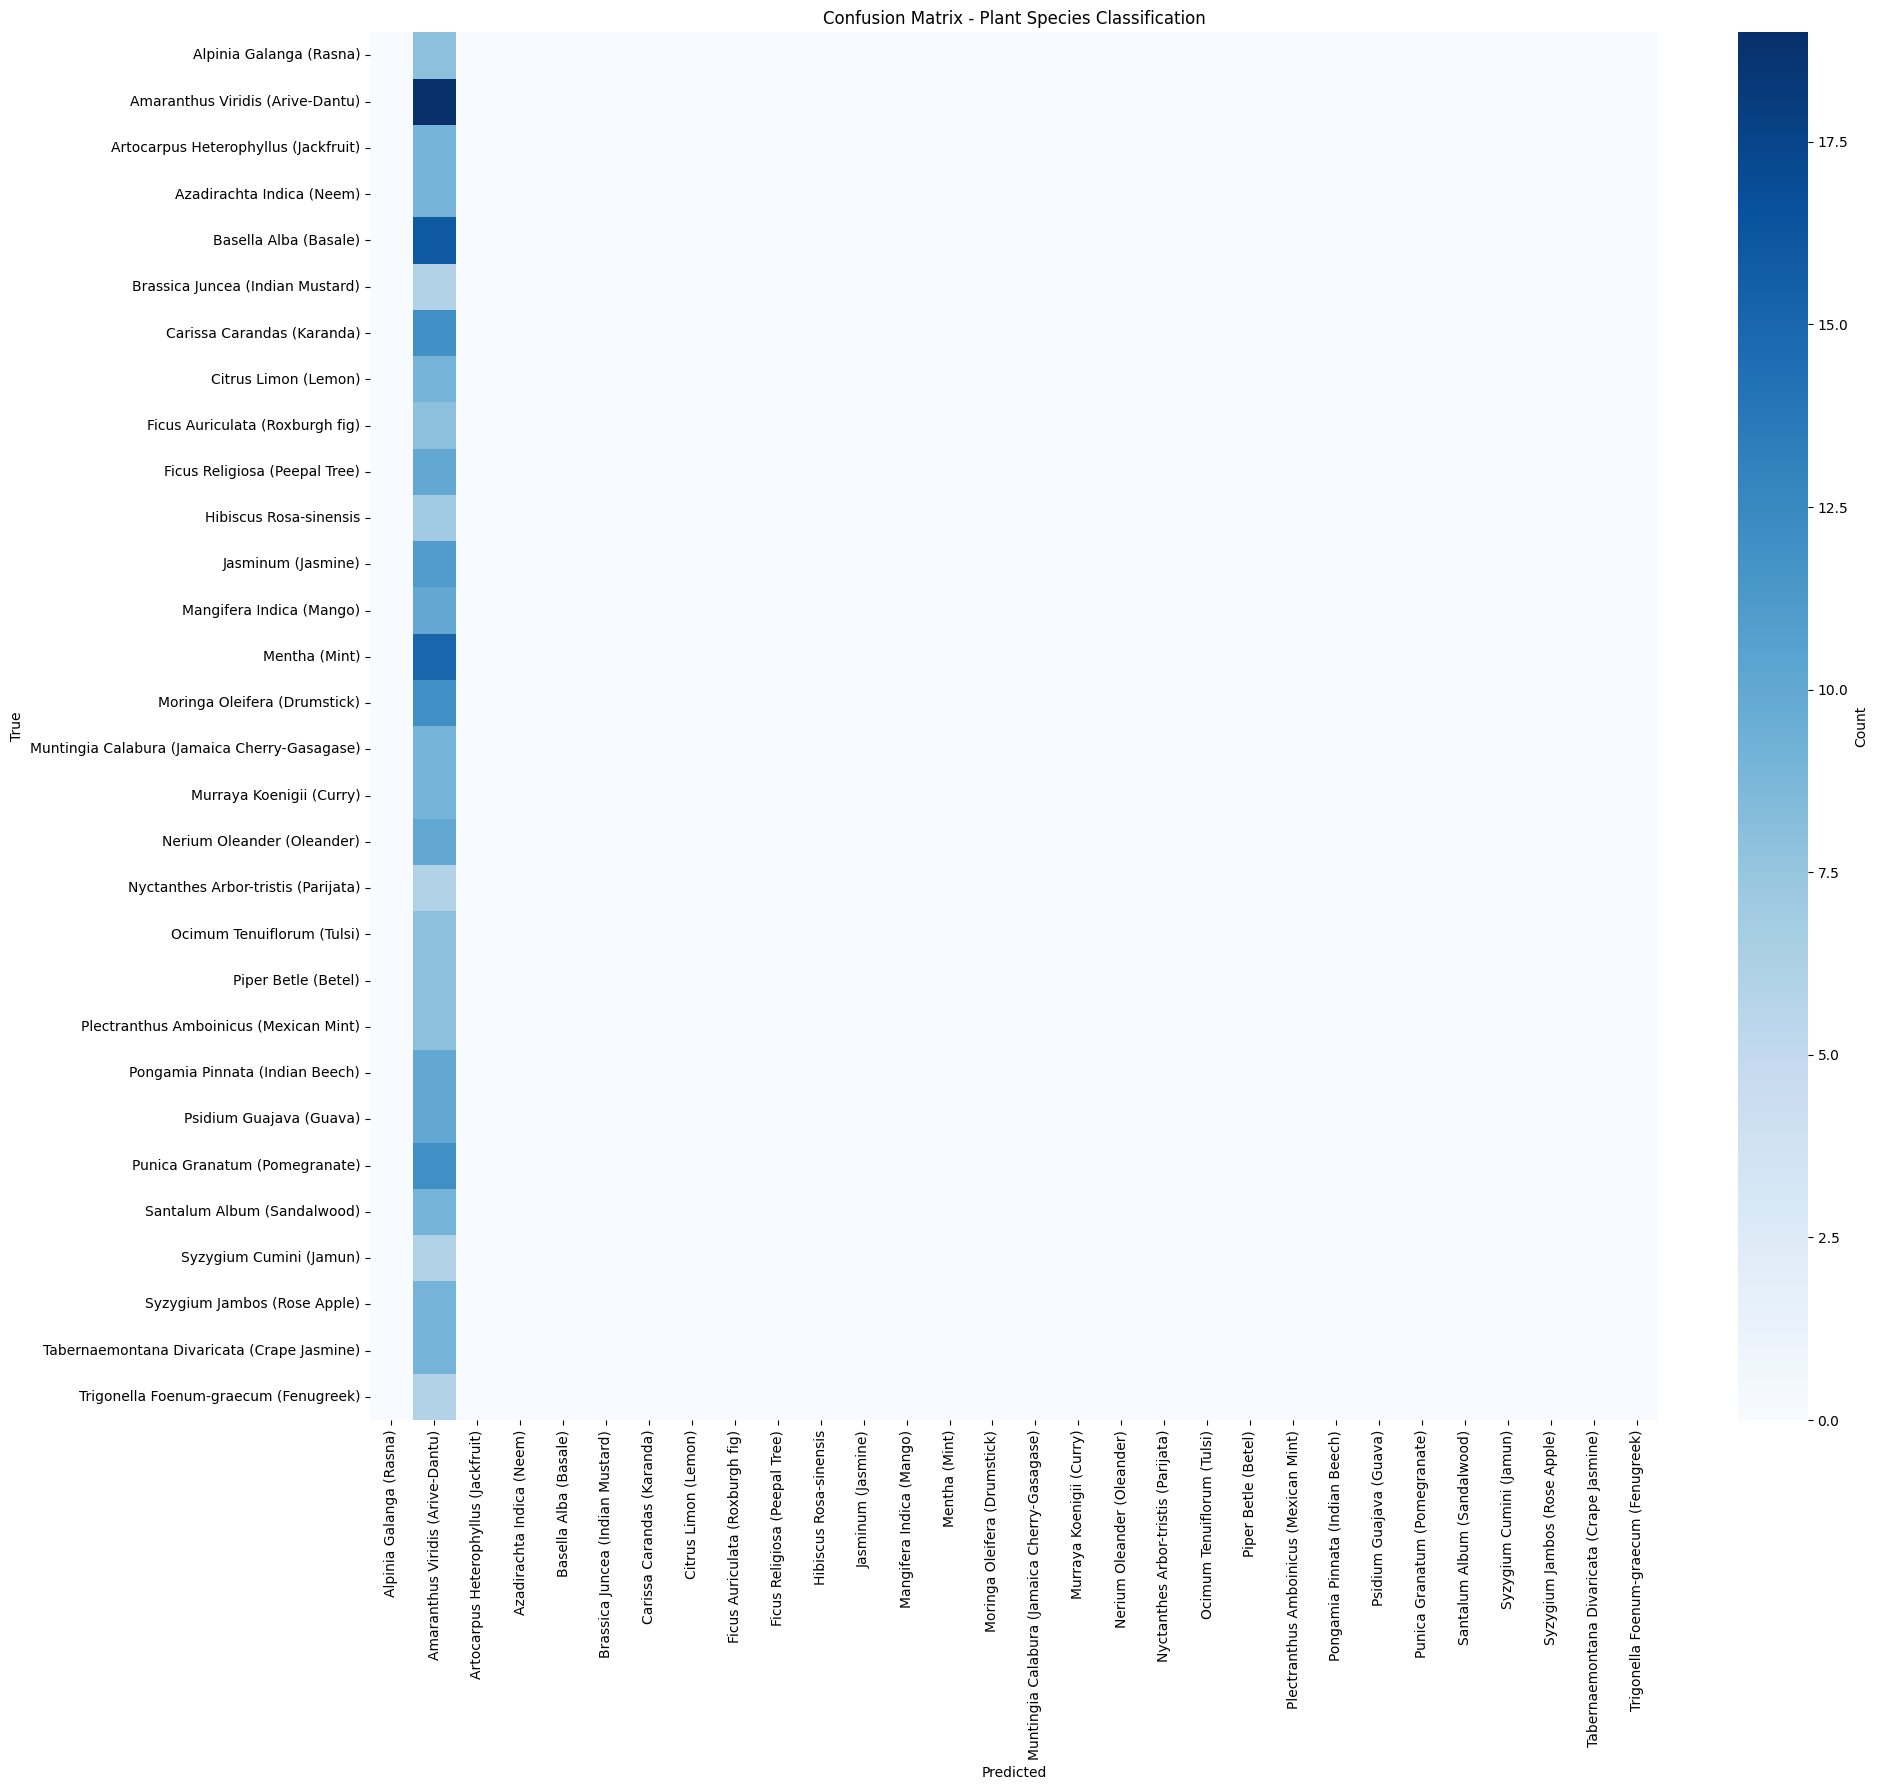

✅ Confusion matrix saved: ../outputs/confusion_matrix.png


In [11]:
# Cell 9: Final Evaluation
print("\n📊 Final Evaluation on Test Set...")
final_results = model.evaluate(test_generator, verbose=1)

print(f"\n🎯 FINAL MODEL PERFORMANCE:")
print("=" * 60)
print(f"   Test Loss:          {final_results[0]:.4f}")
print(f"   Test Accuracy:      {final_results[1]*100:.2f}%")
print(f"   Top-3 Accuracy:     {final_results[2]*100:.2f}%")
print(f"   Top-5 Accuracy:     {final_results[3]*100:.2f}%")
print("=" * 60)

# Calculate per-class accuracy
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\n📋 Classification Report:")
print(classification_report(
    y_true, 
    y_pred, 
    target_names=SPECIES_NAMES,
    digits=3
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 18))
sns.heatmap(
    cm, 
    annot=False, 
    fmt='d', 
    cmap='Blues',
    xticklabels=SPECIES_NAMES,
    yticklabels=SPECIES_NAMES,
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Plant Species Classification')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Confusion matrix saved: {OUTPUTS_DIR}/confusion_matrix.png")


In [13]:
# Cell 10: Save Final Model in Multiple Formats
print("\n💾 Saving models...")

# Save Keras H5 format
h5_path = f'{MODEL_OUTPUT}/{MODEL_NAME}_final.h5'
model.save(h5_path)
print(f"✅ Saved: {h5_path}")

# Save as SavedModel format (intermediate step for TFLite)
saved_model_dir = f'{MODEL_OUTPUT}/{MODEL_NAME}_savedmodel'
model.export(saved_model_dir)
print(f"✅ Saved: {saved_model_dir}")

# Convert SavedModel to TFLite
print("\n🔄 Converting to TFLite...")
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

try:
    tflite_model = converter.convert()
    
    tflite_path = f'{MODEL_OUTPUT}/{MODEL_NAME}.tflite'
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    print(f"✅ Saved: {tflite_path}")
    
    # Get model size
    h5_size = os.path.getsize(h5_path) / (1024*1024)
    tflite_size = os.path.getsize(tflite_path) / (1024*1024)
    
    print(f"\n📊 Model Sizes:")
    print(f"   H5 format:     {h5_size:.2f} MB")
    print(f"   TFLite format: {tflite_size:.2f} MB")
    print(f"   Compression:   {(1 - tflite_size/h5_size)*100:.1f}% smaller")
    
except Exception as e:
    print(f"⚠️ TFLite conversion failed: {e}")
    print("   H5 model saved successfully and can be used for predictions")



💾 Saving models...
✅ Saved: ../models/plant_species_identifier_final.h5
INFO:tensorflow:Assets written to: ../models/plant_species_identifier_savedmodel\assets


INFO:tensorflow:Assets written to: ../models/plant_species_identifier_savedmodel\assets


Saved artifact at '../models/plant_species_identifier_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 30), dtype=tf.float32, name=None)
Captures:
  1654253684304: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1654253686032: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1654217707344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1654217707152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1654217704848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1654217708112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1654217703504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1654217708880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1654217710608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1654217710800: TensorSpec(shape=(), dtype=tf.resource,

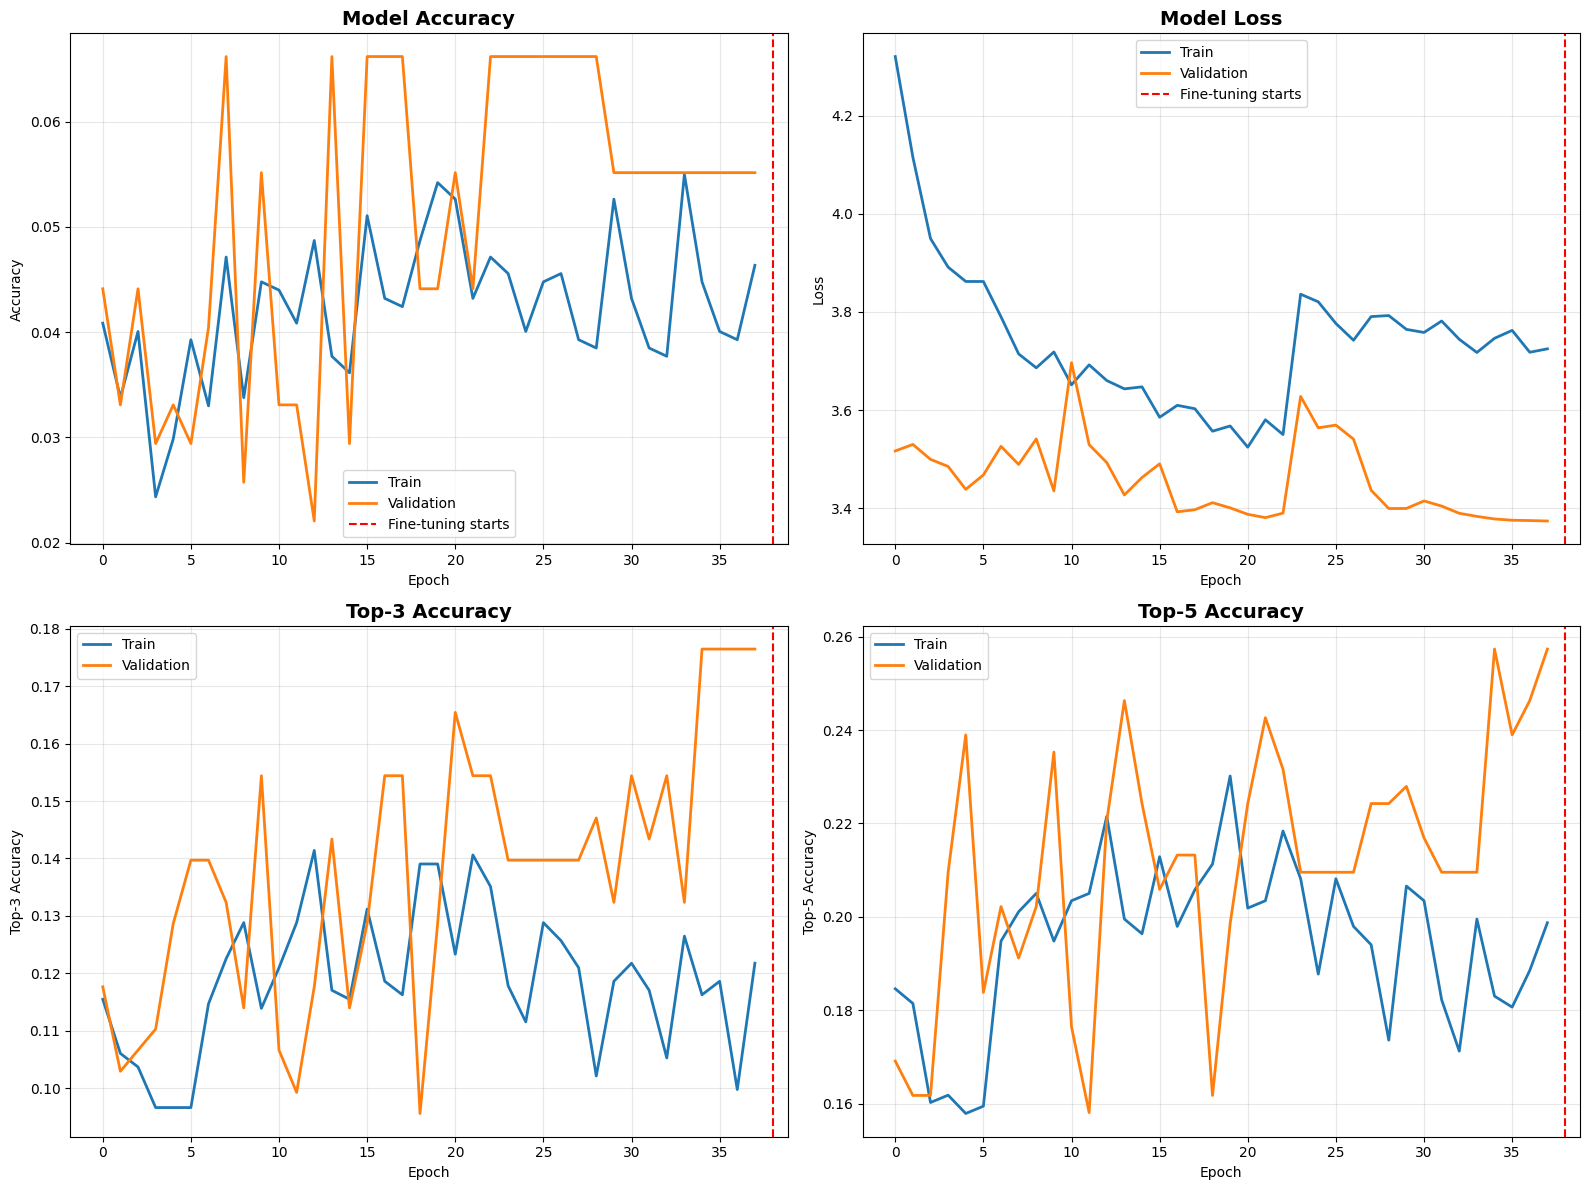

✅ Training curves saved: ../outputs/training_history.png


In [14]:
# Cell 11: Plot Training History
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Combine both training phases
all_history = history.history.copy()
if history_fine:
    for key in all_history.keys():
        all_history[key].extend(history_fine.history[key])

# Accuracy
axes[0, 0].plot(all_history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(all_history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].axvline(x=len(history.history['accuracy']), color='red', linestyle='--', label='Fine-tuning starts')
axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(all_history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(all_history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].axvline(x=len(history.history['loss']), color='red', linestyle='--', label='Fine-tuning starts')
axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Top-3 Accuracy
axes[1, 0].plot(all_history['top_3_accuracy'], label='Train', linewidth=2)
axes[1, 0].plot(all_history['val_top_3_accuracy'], label='Validation', linewidth=2)
axes[1, 0].axvline(x=len(history.history['top_3_accuracy']), color='red', linestyle='--')
axes[1, 0].set_title('Top-3 Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Top-3 Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Top-5 Accuracy
axes[1, 1].plot(all_history['top_5_accuracy'], label='Train', linewidth=2)
axes[1, 1].plot(all_history['val_top_5_accuracy'], label='Validation', linewidth=2)
axes[1, 1].axvline(x=len(history.history['top_5_accuracy']), color='red', linestyle='--')
axes[1, 1].set_title('Top-5 Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Top-5 Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Training curves saved: {OUTPUTS_DIR}/training_history.png")


🔍 Testing predictions on random samples...



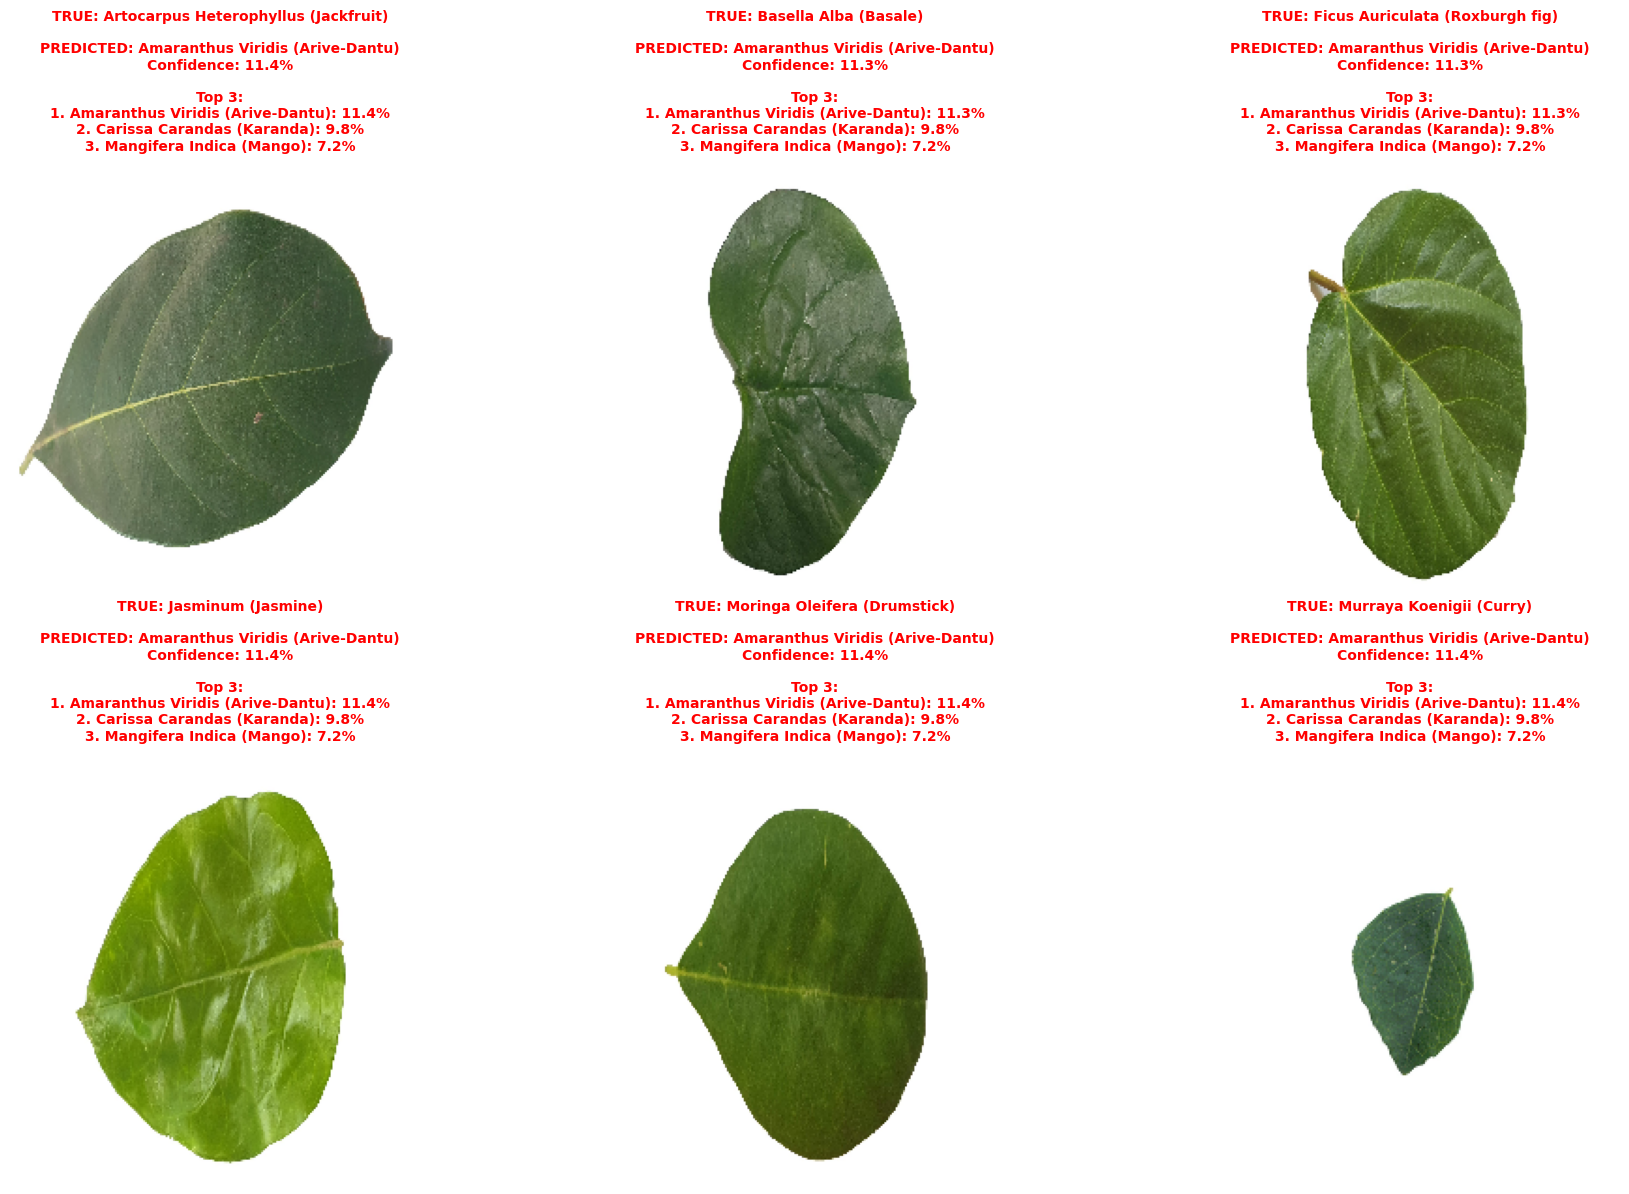

✅ Sample predictions saved: ../outputs/prediction_samples.png


In [15]:
# Cell 12: Test Sample Predictions with Real Names
import random

print("🔍 Testing predictions on random samples...\n")

# Get random test images
num_samples = 6
test_generator.reset()
sample_images = []
sample_labels = []

for _ in range(num_samples):
    img_batch, label_batch = next(test_generator)
    idx = random.randint(0, len(img_batch)-1)
    sample_images.append(img_batch[idx])
    sample_labels.append(np.argmax(label_batch[idx]))

sample_images = np.array(sample_images)

# Predict
predictions = model.predict(sample_images, verbose=0)

# Display results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (img, true_label, pred) in enumerate(zip(sample_images, sample_labels, predictions)):
    top_3_indices = np.argsort(pred)[-3:][::-1]
    
    axes[idx].imshow(img)
    axes[idx].axis('off')
    
    # Show true and predicted species names
    true_species = SPECIES_NAMES[true_label]
    pred_species = SPECIES_NAMES[top_3_indices[0]]
    confidence = pred[top_3_indices[0]] * 100
    
    # Color: green if correct, red if wrong
    color = 'green' if true_label == top_3_indices[0] else 'red'
    
    title = f"TRUE: {true_species}\n\n"
    title += f"PREDICTED: {pred_species}\n"
    title += f"Confidence: {confidence:.1f}%\n\n"
    title += "Top 3:\n"
    for i, pred_idx in enumerate(top_3_indices[:3]):
        title += f"{i+1}. {SPECIES_NAMES[pred_idx]}: {pred[pred_idx]*100:.1f}%\n"
    
    axes[idx].set_title(title, fontsize=10, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/prediction_samples.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Sample predictions saved: {OUTPUTS_DIR}/prediction_samples.png")


In [16]:
# Cell 13: Export Configuration for Mobile App
import json

species_export = {
    'num_classes': NUM_CLASSES,
    'species_names': SPECIES_NAMES,
    'model_input_size': IMG_SIZE,
    'model_name': MODEL_NAME,
    'training_date': datetime.now().isoformat(),
    'test_accuracy': float(final_results[1]),
    'top3_accuracy': float(final_results[2]),
    'top5_accuracy': float(final_results[3])
}

# Save for mobile app
mobile_config_path = '../PlantIDApp/assets/species_config.json'
os.makedirs(os.path.dirname(mobile_config_path), exist_ok=True)

with open(mobile_config_path, 'w') as f:
    json.dump(species_export, f, indent=2)

print(f"✅ Species config exported: {mobile_config_path}")
print(f"\n📱 Mobile App Configuration:")
print(json.dumps(species_export, indent=2))

# Also save in models folder for reference
with open(f'{MODEL_OUTPUT}/model_config.json', 'w') as f:
    json.dump(species_export, f, indent=2)

print(f"✅ Model config saved: {MODEL_OUTPUT}/model_config.json")


✅ Species config exported: ../PlantIDApp/assets/species_config.json

📱 Mobile App Configuration:
{
  "num_classes": 30,
  "species_names": [
    "Alpinia Galanga (Rasna)",
    "Amaranthus Viridis (Arive-Dantu)",
    "Artocarpus Heterophyllus (Jackfruit)",
    "Azadirachta Indica (Neem)",
    "Basella Alba (Basale)",
    "Brassica Juncea (Indian Mustard)",
    "Carissa Carandas (Karanda)",
    "Citrus Limon (Lemon)",
    "Ficus Auriculata (Roxburgh fig)",
    "Ficus Religiosa (Peepal Tree)",
    "Hibiscus Rosa-sinensis",
    "Jasminum (Jasmine)",
    "Mangifera Indica (Mango)",
    "Mentha (Mint)",
    "Moringa Oleifera (Drumstick)",
    "Muntingia Calabura (Jamaica Cherry-Gasagase)",
    "Murraya Koenigii (Curry)",
    "Nerium Oleander (Oleander)",
    "Nyctanthes Arbor-tristis (Parijata)",
    "Ocimum Tenuiflorum (Tulsi)",
    "Piper Betle (Betel)",
    "Plectranthus Amboinicus (Mexican Mint)",
    "Pongamia Pinnata (Indian Beech)",
    "Psidium Guajava (Guava)",
    "Punica Granatum 

In [17]:
# Cell 14: Training Summary
print("\n" + "=" * 70)
print("  🎉 TRAINING COMPLETE!")
print("=" * 70)

print(f"\n✅ Model Performance:")
print(f"   • Species Count:    {NUM_CLASSES}")
print(f"   • Test Accuracy:    {final_results[1]*100:.2f}%")
print(f"   • Top-3 Accuracy:   {final_results[2]*100:.2f}%")
print(f"   • Top-5 Accuracy:   {final_results[3]*100:.2f}%")

print(f"\n💾 Generated Files:")
print(f"   • {MODEL_OUTPUT}/{MODEL_NAME}_final.h5")
print(f"   • {MODEL_OUTPUT}/{MODEL_NAME}.tflite")
print(f"   • {MODEL_OUTPUT}/model_config.json")
print(f"   • {OUTPUTS_DIR}/training_history.png")
print(f"   • {OUTPUTS_DIR}/confusion_matrix.png")
print(f"   • {OUTPUTS_DIR}/prediction_samples.png")
print(f"   • ../PlantIDApp/assets/species_config.json")

print(f"\n🚀 Next Steps:")
print(f"   1. Review training curves in: {OUTPUTS_DIR}/training_history.png")
print(f"   2. Check confusion matrix for misclassifications")
print(f"   3. Copy TFLite model to mobile app:")
print(f"      cp {MODEL_OUTPUT}/{MODEL_NAME}.tflite PlantIDApp/assets/model/")
print(f"   4. Update PlantIDApp/App.tsx to use real model")
print(f"   5. Test app with real plant images!")

print("=" * 70)



  🎉 TRAINING COMPLETE!

✅ Model Performance:
   • Species Count:    30
   • Test Accuracy:    6.55%
   • Top-3 Accuracy:   14.14%
   • Top-5 Accuracy:   21.03%

💾 Generated Files:
   • ../models/plant_species_identifier_final.h5
   • ../models/plant_species_identifier.tflite
   • ../models/model_config.json
   • ../outputs/training_history.png
   • ../outputs/confusion_matrix.png
   • ../outputs/prediction_samples.png
   • ../PlantIDApp/assets/species_config.json

🚀 Next Steps:
   1. Review training curves in: ../outputs/training_history.png
   2. Check confusion matrix for misclassifications
   3. Copy TFLite model to mobile app:
      cp ../models/plant_species_identifier.tflite PlantIDApp/assets/model/
   4. Update PlantIDApp/App.tsx to use real model
   5. Test app with real plant images!
